# 32 — Multi-Head Attention

[Notebook 31](./31_scaled_dot_product_attention.ipynb) implemented one scaled dot-product attention operation. Here we run several smaller attention operations in parallel, concatenate their results, and apply an output projection.

## Learning objectives

- explain why the model dimension is split across multiple heads;
- convert between sequence and head representations without mixing values;
- trace the shapes of learned query, key, value, and output projections;
- broadcast padding and causal masks across heads;
- implement a multi-head self-attention forward pass;
- interpret attention maps from different heads.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from cs231n_practice.attention import scaled_dot_product_attention_forward

SEED = 42
generator = np.random.default_rng(SEED)
np.set_printoptions(precision=3, suppress=True)


## 1. Why use multiple heads?

A single attention head produces one similarity distribution for each query. Multiple heads give the model several independently learned query, key, and value spaces. One head might emphasize nearby positions while another emphasizes a particular feature or a distant position. These roles are learned rather than assigned manually.

Let the input have shape $(N,L,D)$ and choose $H$ heads. In this notebook, $D$ must be divisible by $H$, and each head uses

$$D_h = D/H.$$

The total width remains $H D_h=D$. Multiple heads therefore do not automatically multiply the representation width.

### Why is this different from one large head?

A single head uses all $D$ projected features to calculate **one softmax distribution over key positions for each query**. That one distribution is then used to mix every value feature. Even though the head has more features, it still makes only one retrieval decision per query.

Multi-head attention calculates a separate score matrix and a separate softmax distribution in every head. For the same query, one head can place most of its weight on one token while another head places its weight on a different token. The model can therefore retrieve several kinds of information simultaneously before concatenating and mixing the results.

The heads also do **not** simply receive fixed slices of the original input features. First, learned matrices project the complete input into $Q$, $K$, and $V$. Every projected feature can depend on every original feature. Splitting afterward gives each head a different learned view of the complete input.

```text
one head:      all projected features -> one attention distribution
multiple heads: different learned views -> several attention distributions
                                      -> concatenate and mix the results
```

### Exercise 1 — Calculate the head dimension


In [2]:
model_dim = 12
num_heads = 3

# validate divisibility and calculate head_dim.
head_dim = model_dim // num_heads

assert head_dim == 4
assert num_heads * head_dim == model_dim


## 2. Split and merge heads

After a learned projection, a tensor has shape $(N,L,D)$. Splitting it into heads requires two operations:

1. reshape $(N,L,D)$ to $(N,L,H,D_h)$;
2. transpose to $(N,H,L,D_h)$.

The transpose matters because attention treats the final two axes as sequence and feature axes. Each `(N, H)` slice can then run attention independently. To merge, reverse the transpose and reshape. No arithmetic is performed: only the organization of the same values changes.

### Exercise 2 — Implement the shape helpers


In [3]:
(1,2) + (3,4)

(1, 2, 3, 4)

In [4]:
def split_heads(x, num_heads):
    """Convert (N, L, D) to (N, H, L, D_h)."""
    # validate D % H, reshape, and transpose.
    assert x.shape[-1] % num_heads == 0
    head_dim = x.shape[-1] // num_heads
    x = x.reshape(x.shape[:-1] + (num_heads, head_dim))
    x = x.transpose(0, 2, 1, 3)
    return x


def merge_heads(x):
    """Convert (N, H, L, D_h) back to (N, L, H * D_h)."""
    # reverse the transpose, then reshape.
    x = x.transpose(0, 2, 1, 3)
    x = x.reshape(x.shape[:-2] + (x.shape[-2] * x.shape[-1],))
    return x


example = np.arange(2 * 5 * 12).reshape(2, 5, 12)
split_example = split_heads(example, num_heads=3)
merged_example = merge_heads(split_example)

assert split_example.shape == (2, 3, 5, 4)
assert merged_example.shape == example.shape
np.testing.assert_array_equal(merged_example, example)


## 3. Learned projections

For self-attention, the same input $X$ supplies queries, keys, and values, but three learned matrices create different representations:

$$Q=XW_Q+b_Q,\qquad K=XW_K+b_K,\qquad V=XW_V+b_V.$$

Here each $W$ has shape $(D,D)$ and each bias has shape $(D,)$. After attention, concatenated head outputs are mixed by another learned projection:

$$Y=\operatorname{Concat}(O_1,\ldots,O_H)W_O+b_O.$$

The projections allow heads to learn different similarity and value spaces. Splitting an unprojected tensor alone would only assign fixed groups of input coordinates to heads.

### Exercise 3 — Project and split Q, K, and V


In [ ]:
batch_size, sequence_length, model_dim = 2, 4, 12
num_heads = 3
x = generator.normal(size=(batch_size, sequence_length, model_dim))

W_query = generator.normal(scale=0.1, size=(model_dim, model_dim))
W_key = generator.normal(scale=0.1, size=(model_dim, model_dim))
W_value = generator.normal(scale=0.1, size=(model_dim, model_dim))
b_query = np.zeros(model_dim)
b_key = np.zeros(model_dim)
b_value = np.zeros(model_dim)

# apply the three affine projections and split each into heads.
query_heads = split_heads(x @ W_query + b_query, num_heads)
key_heads = split_heads(x @ W_key + b_key, num_heads)
value_heads = split_heads(x @ W_value + b_value, num_heads)

expected_shape = (batch_size, num_heads, sequence_length, 4)
assert query_heads.shape == expected_shape
assert key_heads.shape == expected_shape
assert value_heads.shape == expected_shape


In [8]:
x.shape, W_query.shape, (x @ W_query).shape

((2, 4, 12), (12, 12), (2, 4, 12))

In [18]:
arr1 = np.array([[1, 2, 2], [3, 4, 1]])
arr2 = np.array([[1, 0], [1, 0], [2, 2]])
arr3 = np.array([[[1, 0], [1, 0], [2, 2]], [[1, 0], [1, 0], [2, 2]]])
arr1.shape, arr2.shape, arr3.shape, (arr1 @ arr2).shape, (arr1 @ arr3).shape

((2, 3), (3, 2), (2, 3, 2), (2, 2), (2, 2, 2))

In [20]:
arr1 @ arr2, arr1 @ arr3

(array([[7, 4],
        [9, 2]]),
 array([[[7, 4],
         [9, 2]],
 
        [[7, 4],
         [9, 2]]]))

## 4. Masks need a head axis

Scores now have shape $(N,H,L_q,L_k)$. A padding mask that starts as $(N,L_k)$ becomes $(N,1,1,L_k)$: both singleton axes broadcast it over every head and every query. A causal mask can have shape $(1,1,L,L)$ and is shared over the batch and heads.

The same allowed/forbidden relationships normally apply to every head, even though each head calculates different scores and weights.

### Exercise 4 — Build a combined multi-head mask


In [ ]:
token_is_valid = np.array([
    [True, True, True, False],
    [True, True, False, False],
])

# create padding_mask (N, 1, 1, L).
padding_mask = token_is_valid.reshape(token_is_valid.shape[0], 1, 1, token_is_valid.shape[1])
# create causal_mask (1, 1, L, L).
causal_mask = np.tril(np.ones((1, 1, 4, 4), dtype=bool))
combined_mask = padding_mask & causal_mask

assert padding_mask.shape == (2, 1, 1, 4)
assert causal_mask.shape == (1, 1, 4, 4)
assert combined_mask.shape == (2, 1, 4, 4)
np.testing.assert_array_equal(
    combined_mask[0, 0, 3], [True, True, True, False]
)


In [23]:
np.tril(np.ones((1, 1, 4, 4), dtype=int))

array([[[[1, 0, 0, 0],
         [1, 1, 0, 0],
         [1, 1, 1, 0],
         [1, 1, 1, 1]]]])

## 5. Multi-head self-attention forward pass

The complete forward path is:

```text
X -> Q, K, V projections -> split heads
  -> scaled dot-product attention per head
  -> merge heads -> output projection -> Y
```

Our reusable attention function operates on the final two axes and preserves any leading axes. It can therefore process all $(N,H)$ head batches at once—no Python loop over heads is needed.

### Exercise 5 — Implement multi-head self-attention


In [ ]:
def multi_head_self_attention_forward(
    x, W_query, W_key, W_value, W_output,
    b_query, b_key, b_value, b_output,
    num_heads, mask=None,
):
    """Calculate a multi-head self-attention forward pass."""
    # project X to Q, K, and V.
    key = x @ W_key + b_key
    query = x @ W_query + b_query
    value = x @ W_value + b_value
    # split all three tensors into heads.
    key_heads = split_heads(key, num_heads)
    query_heads = split_heads(query, num_heads)
    value_heads = split_heads(value, num_heads)
    # call scaled_dot_product_attention_forward.
    attention_output, weights, _ = scaled_dot_product_attention_forward(
        query_heads, key_heads, value_heads, mask=mask
    )
    # merge the head outputs and apply the output projection.
    merged_attention_output = merge_heads(attention_output)
    output = merged_attention_output @ W_output + b_output
    return output, weights


W_output = generator.normal(scale=0.1, size=(model_dim, model_dim))
b_output = np.zeros(model_dim)
output, weights = multi_head_self_attention_forward(
    x, W_query, W_key, W_value, W_output,
    b_query, b_key, b_value, b_output,
    num_heads=num_heads, mask=combined_mask,
)

assert output.shape == (batch_size, sequence_length, model_dim)
assert weights.shape == (batch_size, num_heads, sequence_length, sequence_length)
np.testing.assert_allclose(weights.sum(axis=-1), 1.0)
np.testing.assert_array_equal(
    weights[~np.broadcast_to(combined_mask, weights.shape)], 0.0
)


## 6. Visualize what different heads retrieve

Randomly initialized projections do not yet have meaningful linguistic roles, but their different parameters already produce different attention maps. During training, the task loss determines which patterns become useful. An attention map is useful diagnostic evidence, but it is not by itself a complete explanation of a model prediction.

### Exercise 6 — Compare the head maps


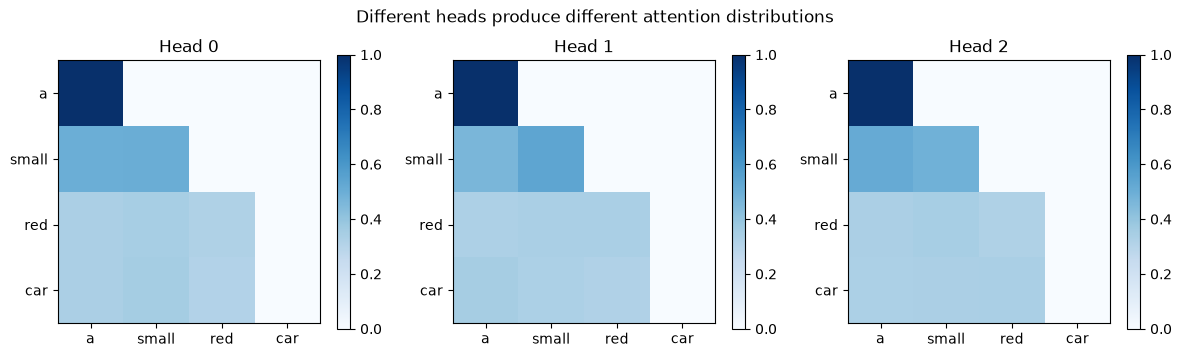

In [28]:
tokens = ["a", "small", "red", "car"]
fig, axes = plt.subplots(1, num_heads, figsize=(4 * num_heads, 3.5))

# display example 0's attention map for every head.
# Give each subplot token labels and a head-number title.
for head in range(num_heads):
    ax = axes[head]
    im = ax.imshow(weights[0, head], cmap="Blues")
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens)
    ax.set_yticklabels(tokens)
    ax.set_title(f"Head {head}")
    fig.colorbar(im, ax=ax)


fig.suptitle("Different heads produce different attention distributions")
plt.tight_layout()
plt.show()


## Reflection

Answer briefly in your own words.

1. Why must `model_dim` be divisible by `num_heads` in this implementation?
2. Why do we transpose from $(N,L,H,D_h)$ to $(N,H,L,D_h)$ after reshaping?
3. What gives different heads the ability to learn different relationships?
4. Why is the mask usually shared across heads?
5. After concatenating the heads, what is the purpose of the output projection?
6. Why should an attention map be interpreted cautiously?

### Answers

1. `model_dim` must be divisible by `num_heads` so that every head receives the same integer number of projected features, $D_h=D/H$, without dropping any features.
2. The transpose produces $(N,H,L,D_h)$, placing the sequence and feature dimensions last. The attention function can then treat every batch-head pair as an independent attention operation.
3. Each head receives a different learned part of the $Q$, $K$, and $V$ projections and calculates its own scores and softmax distribution. This lets different heads learn different retrieval patterns.
4. A padding or causal mask describes which token positions are structurally allowed. These restrictions normally apply to every head, even though the heads assign different weights among the allowed positions.
5. The output projection mixes information from the concatenated heads and maps it back into the model representation space. Without it, the head results would only be placed next to one another.
6. Attention weights show where a head places weight, but they do not describe the complete model computation. The values, output projection, other heads, residual connections, and later layers also affect the final prediction.
